## Video Claim Status Analysis (TikTok)

#### Problem Statement : 
Due to the high volume of content on TikTok, manually determining whether videos contain factual claims or personal opinions is a challenging and time-consuming task. This project analyzes video, engagement, and creator-related features to identify patterns that distinguish claim videos from opinion videos as well as whether user account is verified or not. The findings can assist content moderators in making faster and more accurate moderation decisions, particularly when evaluating potentially misleading or false claims.

### KPQ

1) What percentage of videos are classified as claims versus non-claims?
2) Do claim videos receive more views than non-claim videos?
3) Do claim videos generate higher audience engagement (likes, comments, shares, downloads) than non-claim videos?
4) Which engagement metric (likes, comments, shares, or downloads) have more variation between claim and non-claim videos if considering user ban status?
5) Are verified creators more likely to post claim videos or non-claim videos?
6) How does the performance of claim videos differ between verified and non-verified creators?
7) Do claim videos contain longer transcription text than non-claim videos?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset into dataframe
try:
    df = pd.read_csv("data/tiktok_dataset.csv")
    print("Dataset Loading completed")
except FileNotFoundError as e:
    print(f'Error for file loading is {e}')

Dataset Loading completed


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [4]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Dataset have missing values lets look for them and take appropriate action regarding missing values

In [5]:
df.isnull().sum().sum()

2086

There are total 2086 null values from 19382 values. it is very less compare to total value count so we will remove them

In [6]:
df=df.dropna(axis=0).reset_index(drop=True)
df.isna().sum()

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64

In [7]:
df.duplicated().sum()

0

Dataset is don't have any duplicate or null values anymore we look into some features 

 1) What percentage of videos are classified as claims versus Opinion?

In [8]:
df['claim_status'].value_counts(normalize=True)*100

claim_status
claim      50.345839
opinion    49.654161
Name: proportion, dtype: float64

Both claim and opinion have almost same amout of percentage ~50%

2) Do claim videos receive more views than Opinion videos?

In [9]:
claim = df[df['claim_status']=='claim']
print("Mean view count claims:",claim['video_view_count'].mean())
print("Median view count claims:",claim['video_view_count'].median())

Mean view count claims: 501029.4527477102
Median view count claims: 501555.0


In [10]:
opinion = df[df['claim_status']=='opinion']
print("Mean view count opinion:",opinion['video_view_count'].mean())
print("Median view count opinion:",opinion['video_view_count'].median())

Mean view count opinion: 4956.43224989447
Median view count opinion: 4953.0


Clearly there is very big difference in the view count between claim and opinion labeled video. But there mean and median of both categories are close to each other which can give liitle idea about disribution of data in video_view count

3) Do claim videos generate higher audience engagement (likes, comments, shares, downloads) than Opinion videos?

We will try to find count, mean and median for each feature and we will see whether which videos have higher audience engagement

In [11]:
df.groupby(['claim_status']).agg({
    'video_like_count':['count','mean','median'],
    'video_comment_count':['count','mean','median'],
    'video_share_count':['count','mean','median'],
    'video_download_count':['count','mean','median']
}).round(3)

video_like_count                       video_comment_count  \
                        count        mean    median               count   
claim_status                                                              
claim                    9608  166373.331  123649.0                9608   
opinion                  9476    1092.730     823.0                9476   

                             video_share_count                      \
                 mean median             count       mean   median   
claim_status                                                         
claim         691.165  286.0              9608  33026.416  17997.5   
opinion         2.697    1.0              9476    217.146    121.0   

             video_download_count                    
                            count      mean  median  
claim_status                                         
claim                        9608  2070.952  1139.5  
opinion                      9476    13.677     7.0

From Above result we can see clearly there is vast difference between claim and opinion labeled videos engagement. Claim labeled videos have high like,comment,and download mean and median compare to opinion label video. Both categories have almost similar number of counts there is ~200 differece between them.

4) Which engagement metric (likes, comments, shares, or downloads) have more variation between claim and non-claim videos if considering user ban status?

In [12]:
df.groupby(['claim_status','author_ban_status']).agg({
    'video_like_count':['count','mean','median'],
    'video_comment_count':['count','mean','median'],
    'video_share_count':['count','mean','median'],
    'video_download_count':['count','mean','median']
}).round(3)

video_like_count                        \
                                          count        mean    median   
claim_status author_ban_status                                          
claim        active                        6566  164960.303  121943.0   
             banned                        1439  173719.103  132044.0   
             under review                  1603  165566.954  125882.0   
opinion      active                        8817    1091.715     820.0   
             banned                         196    1027.515     799.5   
             under review                   463    1139.663     876.0   

                               video_comment_count                  \
                                             count     mean median   
claim_status author_ban_status                                       
claim        active                           6566  687.828  286.0   
             banned                           1439  698.402  296.0   
             under review                     1603  698.336  279.0   
opinion      active                           8817    2.697    1.0   
             banned                            196    2.311    1.0   
             under review                      463    2.877    1.0   

                               video_share_count                      \
                                           count       mean   median   
claim_status author_ban_status                                         
claim        active                         6566  32769.102  17774.5   
             banned                         1439  34056.581  19018.0   
             under review                   1603  33155.623  18084.0   
opinion      active                         8817    217.167    121.0   
             banned                          196    208.423    108.5   
             under review                    463    220.432    124.0   

                               video_download_count                    
                                              count      mean  median  
claim_status author_ban_status                                         
claim        active                            6566  2048.670  1124.5  
             banned                            1439  2141.458  1204.0  
             under review                      1603  2098.931  1153.0  
opinion      active                            8817    13.666     7.0  
             banned                             196    12.939     6.0  
             under review                       463    14.205     8.0

From above we have similar effect as previous but here one thing is noticable in both category claim and opinion, banned users count is very less than active users but they have almost similar like,comment and downloads on thier video. which leads to one thing user who are getting banned having higher engagement than other users.

we will create new columns to help better understand of engagement 

In [13]:
# Create a likes_per_view column
df['like_per_view']  = df['video_like_count']/df['video_view_count']

# Create a comment_per_view column
df['comment_per_view']  = df['video_comment_count']/df['video_view_count']

# Create a shares_per_view column
df['share_per_view']  = df['video_share_count']/df['video_view_count']

df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,comment_per_view,share_per_view
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175


lets calculate Mean, Median and Count for the newly created column, considering Author band status and claim status as category

In [14]:
df.groupby(['claim_status','author_ban_status']).agg({
    'like_per_view':['count','mean','median'],
    'comment_per_view':['count','mean','median'],
    'share_per_view':['count','mean','median']
}).round(5)

like_per_view                    \
                                       count     mean   median   
claim_status author_ban_status                                   
claim        active                     6566  0.32954  0.32654   
             banned                     1439  0.34507  0.35891   
             under review               1603  0.32800  0.32087   
opinion      active                     8817  0.21974  0.21833   
             banned                      196  0.20687  0.19848   
             under review                463  0.22639  0.22805   

                               comment_per_view                    \
                                          count     mean   median   
claim_status author_ban_status                                      
claim        active                        6566  0.00139  0.00078   
             banned                        1439  0.00138  0.00075   
             under review                  1603  0.00137  0.00079   
opinion      active                        8817  0.00052  0.00025   
             banned                         196  0.00043  0.00019   
             under review                   463  0.00054  0.00029   

                               share_per_view                    
                                        count     mean   median  
claim_status author_ban_status                                   
claim        active                      6566  0.06546  0.04928  
             banned                      1439  0.06789  0.05161  
             under review                1603  0.06573  0.04997  
opinion      active                      8817  0.04373  0.03240  
             banned                       196  0.04053  0.03073  
             under review                 463  0.04447  0.03503

We know that videos by banned authors and those under review tend to get far more views, likes, and shares than videos by non-banned authors if we considering number of users.

Also, we know that claim videos have a higher view rate than opinion videos, but this tells us that claim videos also have a higher rate of likes on average, so they are more favorably received as well. also, they receive more engagement via comments and shares than opinion videos.

for claim videos, banned authors have higher likes/view and shares/view rates than active authors or those under review. However, for opinion videos, active authors and those under review both get higher mean and Median than banned authors

5) Are verified creators more likely to post claim videos or non-claim videos?

In [15]:
res=pd.crosstab(df['claim_status'],df['verified_status'])
res

verified_status,not verified,verified
claim_status,,
claim,9399,209
opinion,8485,991


There is very big number for not verified user posting claim labeld videos than verified. similar with opinion labeled videos however for opinion videos verified user is count is larger than claim labeled video 

6) How does the performance of claim videos differ between verified and non-verified creators?

We have already seen the performace between claim and opinion video considering author ban status we can check engagement level of claim and opinion videos considering whether user is verified or not

In [16]:
df.groupby(['claim_status','verified_status']).agg({
    'video_view_count':['count','mean','median'],
    'video_like_count':['count','mean','median'],
    'video_comment_count':['count','mean','median'],
    'video_share_count':['count','mean','median'],
    'video_download_count':['count','mean','median']
}).round(3)

video_view_count                        \
                                        count        mean    median   
claim_status verified_status                                          
claim        not verified                9399  501016.618  501453.0   
             verified                     209  501606.651  502375.0   
opinion      not verified                8485    4958.862    4950.0   
             verified                     991    4935.628    4958.0   

                             video_like_count                        \
                                        count        mean    median   
claim_status verified_status                                          
claim        not verified                9399  166313.777  123480.0   
             verified                     209  169051.560  132633.0   
opinion      not verified                8485    1093.851     820.0   
             verified                     991    1083.132     842.0   

                             video_comment_count                  \
                                           count     mean median   
claim_status verified_status                                       
claim        not verified                   9399  689.586  285.0   
             verified                        209  762.158  324.0   
opinion      not verified                   8485    2.711    1.0   
             verified                        991    2.585    1.0   

                             video_share_count                      \
                                         count       mean   median   
claim_status verified_status                                         
claim        not verified                 9399  32941.778  17952.0   
             verified                      209  36832.694  23294.0   
opinion      not verified                 8485    217.557    122.0   
             verified                      991    213.628    119.0   

                             video_download_count                    
                                            count      mean  median  
claim_status verified_status                                         
claim        not verified                    9399  2072.668  1141.0  
             verified                         209  1993.785  1099.0  
opinion      not verified                    8485    13.734     7.0  
             verified                         991    13.194     7.0

Like previous results, here claim labeled videos outperform the opinion labeld videos irrespective of verified status. We can see Verified status haven't much effect on claim status videos. Both verified and not verified user have almost simialar engagement in claim labled vidoes.

7) Do claim videos contain longer transcription text than non-claim videos?

In [17]:
df["text_length"] = df['video_transcription_text'].apply(func= lambda text:len(text))
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,like_per_view,comment_per_view,share_per_view,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175,128


In [18]:
df.groupby(['claim_status']).agg({'text_length':['mean','median']})

text_length       
                    mean median
claim_status                   
claim          95.376978   93.0
opinion        82.722562   80.0

we will plot Histogram for text length for claim and opinion

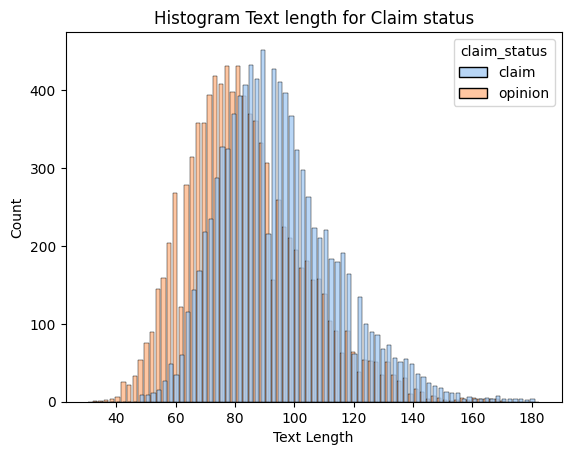

In [19]:
plt.Figure(figsize=(18,8))
sns.histplot(data=df,x='text_length',hue='claim_status',stat='count',multiple='dodge',palette='pastel',legend=True,kde=False,shrink=1.5)
plt.title('Histogram Text length for Claim status')
plt.xlabel('Text Length')
plt.ylabel("Count")
plt.show()

claim videos have approximately 13 word more than opinion videos. After plotting distribution we can see both categories have normal bell shape distribution and don't have much difference.  which leads to may be Its not strong indicator for predicting whether video is claim or opinion

#### We are going to use this same dataset for prediction model so we will try to clean and impute outliers in same notebook for futher use.

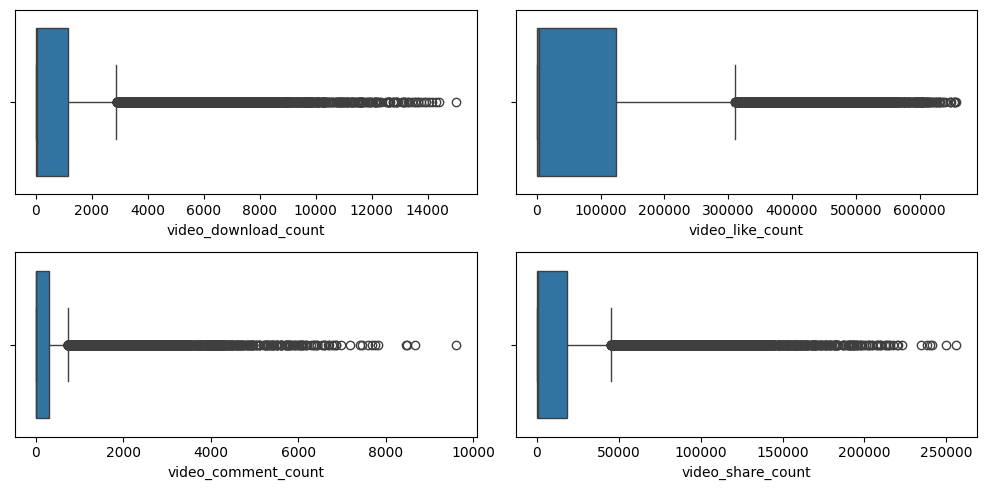

In [20]:
fig, ax = plt.subplots(2,2,figsize=(10,5))
sns.boxplot(x=df['video_download_count'],ax=ax[0,0])
sns.boxplot(x=df['video_like_count'],ax=ax[0,1])
sns.boxplot(x=df['video_comment_count'],ax=ax[1,0])
sns.boxplot(x=df['video_share_count'],ax=ax[1,1])
plt.tight_layout()
plt.show()

Most of the numerical features contain outliers and are skewed. In future,to prevent extreme values from disproportionately affecting model predictions, a function will be created to treat outliers using the 1.5 × IQR method.

In [21]:
def impute_outliers(columns):
    """
        Iterates through the specified columns and calculates the first (Q1) and third (Q3) quartiles for each column.
        The Interquartile Range (IQR) is then computed as Q3 - Q1. Values falling below the lower bound
        (Q1 - 1.5 * IQR) or above the upper bound (Q3 + 1.5 * IQR) are capped at their respective boundary values.
    """

    for col_name in columns:
        Q1 = df[col_name].quantile(0.25)
        Q3 = df[col_name].quantile(0.75)

        IQR = Q3-Q1

        lower_limit = Q1-(1.5*IQR)
        upper_limit = Q3+(1.5*IQR)

        df.loc[df[col_name]<lower_limit,col_name]=lower_limit
        df.loc[df[col_name]>upper_limit,col_name]=upper_limit


In [22]:
#let impute outliers from columns 

impute_outliers(['video_like_count','video_share_count','video_download_count','video_comment_count'])

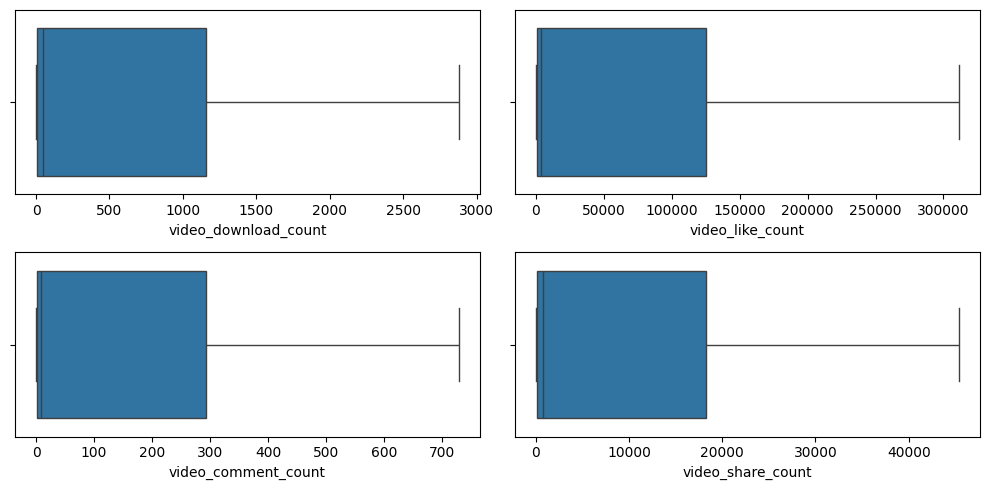

In [23]:
fig, ax = plt.subplots(2,2,figsize=(10,5))
sns.boxplot(x=df['video_download_count'],ax=ax[0,0])
sns.boxplot(x=df['video_like_count'],ax=ax[0,1])
sns.boxplot(x=df['video_comment_count'],ax=ax[1,0])
sns.boxplot(x=df['video_share_count'],ax=ax[1,1])
plt.tight_layout()
plt.show()

There is one of the future objective of analysis to identify whether user is verified or not. considering that is target variable, Lets check class balance for given target feature.

In [24]:
df['verified_status'].value_counts(normalize=True)*100

verified_status
not verified    93.71201
verified         6.28799
Name: proportion, dtype: float64

target Feature is absolutely imbalanced. 93.7% of dataset represent video posted by unverified accounts and inly 6.3% posted by verified account.
Using resampling to create class balance in the outcome variable.

In [25]:
#just for this Cell to perform resample operation we will use sklearn library
from sklearn.utils import resample
#Using resampling to create class balanced in outcome variable 

major_data = df[df['verified_status']=='not verified']
minor_data = df[df['verified_status']=='verified']

#upsampling the minor data

upsample_minor_data = resample(minor_data,
                               replace=True,
                               n_samples=len(major_data),
                               random_state = 0)

df_upsampled = pd.concat([major_data,upsample_minor_data]).reset_index(drop=True)

df_upsampled['verified_status'].value_counts()

verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

We are going to use the same dataset for Regression analysis so we will save the dataset in csv file for future use

In [26]:
df.to_csv('data/Cleaned_tiktok_dataset.csv',index=False)